# <font color=' palegreen'>Data Science CA</font>

<font color='palegreen'>Aidin Kazemi: 810101561</font>

<font color='palegreen'>Ali Zilouchi: 810101560</font>

<font color='palegreen'>Paria Pasehvarz: 810101393</font>

## <font color='orange'>**Task 3 - LLM for MCQs**</font>

### <font color='skyblue'>1. Hugging face access token</font>

In [1]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# Initialize the UserSecretsClient
user_secrets = UserSecretsClient()

# Get the stored secret
hf_token = user_secrets.get_secret("HF_TOKEN")

# Login to Hugging Face using the secret
login(token=hf_token)

### <font color='skyblue'>2. Loading the dataset</font>

In [2]:
from datasets import load_dataset

# Load the "regular" configuration of the SWAG dataset
swag_dataset = load_dataset("swag", "regular")

# Print the dataset object to see its structure
print(swag_dataset)

README.md: 0.00B [00:00, ?B/s]

regular/train-00000-of-00001.parquet:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

regular/validation-00000-of-00001.parque(…):   0%|          | 0.00/4.81M [00:00<?, ?B/s]

regular/test-00000-of-00001.parquet:   0%|          | 0.00/4.78M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/73546 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/20006 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20005 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 73546
    })
    validation: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 20006
    })
    test: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 20005
    })
})


In [3]:
# Access the training split and view the first example
example = swag_dataset["train"][0]

# Print the example to see its fields
for key, value in example.items():
    print(f"{key}: {value}")

video-id: anetv_jkn6uvmqwh4
fold-ind: 3416
startphrase: Members of the procession walk down the street holding small horn brass instruments. A drum line
sent1: Members of the procession walk down the street holding small horn brass instruments.
sent2: A drum line
gold-source: gold
ending0: passes by walking down the street playing their instruments.
ending1: has heard approaching them.
ending2: arrives and they're outside dancing and asleep.
ending3: turns the lead singer watches the performance.
label: 0


### <font color='skyblue'>3. Analyse the dataset </font>

Each row represents a distinct commonsense reasoning problem. The goal is to choose the most logical continuation of a sentence describing a video clip.

* startphrase / sent1: This is the first part of the context, setting the scene. It's often a complete sentence.

* sent2: This is the second sentence of the context, describing an action that follows the first sentence. The model's task is to predict what logically happens next.

* ending0, ending1, ending2, ending3: These are the four possible multiple-choice options that could follow sent2.

label: This is the ground truth. It's an integer (0, 1, 2, or 3) indicating which of the endings is the correct, most logical continuation.

* gold-source: This indicates the origin of the correct answer (the "gold" standard). For this dataset, the correct endings come from the video captions themselves, while the incorrect ones (distractors) are machine-generated.

So, for each example, a model must understand the context provided by sent1 + sent2 and determine which of the four endings is the most plausible, as indicated by the label.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the training split to a Pandas DataFrame for easier analysis
df = swag_dataset["train"].to_pandas()

#### 1. Label Distribution

Let's see if the correct answers are evenly distributed among the four choices. An imbalanced distribution could potentially bias a model.

label
0    18414
1    18334
2    18340
3    18458
Name: count, dtype: int64


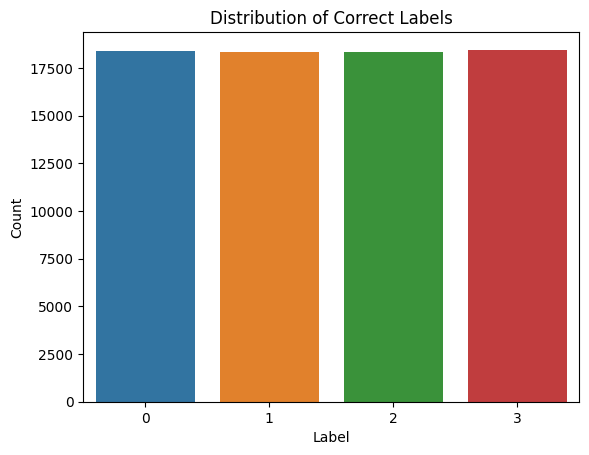

In [5]:
# Check the distribution of the labels
label_counts = df['label'].value_counts().sort_index()
print(label_counts)

# Plot the distribution
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribution of Correct Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

The dataset is perfectly balanced. Each of the four choices (0, 1, 2, 3) appears as the correct answer an almost equal number of times. This is ideal, as it prevents the model from simply learning to favor one position over the others.

#### 2. Text Length Analysis

Let's analyze the length of the sentences. This helps us understand the complexity and the amount of text a model needs to process for each example.

In [6]:
# Calculate the number of words in the context and endings
df['context_length'] = df['sent1'].str.split().str.len() + df['sent2'].str.split().str.len()
df['ending0_length'] = df['ending0'].str.split().str.len()
df['ending1_length'] = df['ending1'].str.split().str.len()
df['ending2_length'] = df['ending2'].str.split().str.len()
df['ending3_length'] = df['ending3'].str.split().str.len()

# Display summary statistics for the lengths
print(df[['context_length', 'ending0_length', 'ending1_length', 'ending2_length', 'ending3_length']].describe())

       context_length  ending0_length  ending1_length  ending2_length  \
count    73546.000000    73546.000000    73546.000000    73546.000000   
mean        14.057991        8.572852        8.606763        8.579828   
std          6.744379        3.975163        3.989374        3.996487   
min          4.000000        1.000000        1.000000        1.000000   
25%          9.000000        5.000000        6.000000        5.000000   
50%         13.000000        8.000000        8.000000        8.000000   
75%         17.000000       11.000000       11.000000       11.000000   
max        101.000000       25.000000       25.000000       25.000000   

       ending3_length  
count    73546.000000  
mean         8.557787  
std          3.987558  
min          1.000000  
25%          5.000000  
50%          8.000000  
75%         11.000000  
max         25.000000  


The text segments are relatively short. On average, the context is about 14 words long, and each ending is around 7-9 words long. The maximum lengths are also manageable, so we likely won't need to worry about complex text truncation strategies for most models.

#### 3. Source of Correct Endings

Let's check the gold-source column to see where the correct answers came from.

In [7]:
# Check the unique values and their counts in the 'gold-source' column
print(df['gold-source'].value_counts())

gold-source
gold    47928
gen     25618
Name: count, dtype: int64


This means the correct endings in your training set come from two different origins:

* gold (47,928 examples): This represents the "gold standard" answers. These are the endings taken directly from the original source, which are the human-written video captions. They represent natural, real-world continuations.

* gen (25,618 examples): This likely stands for "generated." It indicates that for a significant portion of the dataset, the correct answer was also generated, though likely by a different, more reliable process than the one used to create the incorrect distractors.

### <font color='skyblue'>4. Preprocess the dataset </font>

#### 1. Setup the Tokenizer

This step initializes the tokenizer that will convert our text into numerical IDs the model can understand.

In [8]:
from transformers import AutoTokenizer

# Load a tokenizer. DistilBERT is a good, fast choice.
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

#### 2. Create the Preprocessing Function

This function will take a batch of examples from the dataset and restructure them into the required format.

In [9]:
def preprocess_function(examples):
    contexts = [f"{s1} {s2}" for s1, s2 in zip(examples['sent1'], examples['sent2'])]
    first_sentences = [context for context in contexts for _ in range(4)]
    
    second_sentences = []
    for i in range(len(examples['sent1'])):
        second_sentences.append(examples['ending0'][i])
        second_sentences.append(examples['ending1'][i])
        second_sentences.append(examples['ending2'][i])
        second_sentences.append(examples['ending3'][i])
        
    tokenized_examples = tokenizer(first_sentences, second_sentences, truncation=True)
    
    result = {k: [v[i:i+4] for i in range(0, len(v), 4)] for k, v in tokenized_examples.items()}
    result["label"] = examples["label"]
    return result

# Re-run the map function
tokenized_swag = swag_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/73546 [00:00<?, ? examples/s]

Map:   0%|          | 0/20006 [00:00<?, ? examples/s]

Map:   0%|          | 0/20005 [00:00<?, ? examples/s]

#### 3. Apply the Function to the Dataset

Now, we use the .map() method to apply this function across the entire SWAG dataset. Using batched=True is essential for efficiency and allows our function to process multiple examples at once.

In [10]:
# Apply the preprocessing function to the entire dataset
tokenized_swag = swag_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/73546 [00:00<?, ? examples/s]

#### 4. Verify the Output

In [11]:
# Inspect the first example
example = tokenized_swag["train"][0]

# Print the keys to see the new structure
print(example.keys())

# Check the shape of the input_ids. It should be 4 lists of token IDs.
print(f"\nNumber of choices: {len(example['input_ids'])}")
print(f"Length of first choice's tokens: {len(example['input_ids'][0])}")

# Decode the first tokenized choice to see the final formatted input
print("\nDecoded first full input:")
print(tokenizer.decode(example['input_ids'][0]))

dict_keys(['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label', 'input_ids', 'attention_mask'])

Number of choices: 4
Length of first choice's tokens: 30

Decoded first full input:
[CLS] members of the procession walk down the street holding small horn brass instruments. a drum line [SEP] passes by walking down the street playing their instruments. [SEP]


### <font color='skyblue'>5. Load a tokenizer </font>

In [12]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### <font color='skyblue'>6. Apply the preprocessing function  </font>

In [13]:
# Apply the preprocessing function to the entire dataset
tokenized_swag = swag_dataset.map(preprocess_function, batched=True)

# You can then print the result to see the updated dataset structure
print(tokenized_swag)

Map:   0%|          | 0/73546 [00:00<?, ? examples/s]

Map:   0%|          | 0/20006 [00:00<?, ? examples/s]

Map:   0%|          | 0/20005 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 73546
    })
    validation: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20006
    })
    test: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20005
    })
})


### <font color='skyblue'>7. Padding </font>

In [14]:
from transformers import DataCollatorForMultipleChoice

# Initialize the data collator
# It needs the tokenizer to know which token to use for padding
data_collator = DataCollatorForMultipleChoice(tokenizer=tokenizer)

2025-09-08 09:15:51.447575: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757322951.656589      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757322951.722229      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### <font color='skyblue'>8. Load the model </font>

In [15]:
from transformers import AutoModelForMultipleChoice, TrainingArguments, Trainer
model = AutoModelForMultipleChoice.from_pretrained("google-bert/bert-base-uncased")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForMultipleChoice were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### <font color='skyblue'>9. Test the model on the dataset </font>

#### 1. Test Case Analysis

In [16]:
# Tell the dataset to only return these columns as PyTorch tensors
columns_to_keep = ['input_ids', 'token_type_ids', 'attention_mask', 'label']
tokenized_swag.set_format(type='torch', columns=columns_to_keep)

In [17]:
import torch

# --- Final Corrected Analysis Block ---

# 1. Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2. Select the example
example_index = 42
# Get the full example from the correctly preprocessed dataset
single_example = tokenized_swag["validation"][example_index]
# Get the original text for printing the final analysis
original_example = swag_dataset["validation"][example_index]

# 3. Manually create a clean dictionary for the collator
# This ensures the collator only sees the data it can handle.
features_for_collator = {
    "input_ids": single_example["input_ids"],
    "attention_mask": single_example["attention_mask"],
    "token_type_ids": single_example["token_type_ids"],
    "label": single_example["label"]
}

# 4. Pass the clean dictionary to the collator
# Note: it must be wrapped in a list.
collated_batch = data_collator([features_for_collator])

# 5. Move the collated batch to the correct device
collated_batch = {k: v.to(device) for k, v in collated_batch.items()}

# 6. Perform inference
model.eval()
with torch.no_grad():
    outputs = model(**collated_batch)

logits = outputs.logits
predicted_label = logits.argmax().item()
# Get the ground truth from the original, complete example
ground_truth_label = single_example['label'] 

# --- Analysis ---
print(f"Context: {original_example['startphrase']}")
print("-" * 30)
for i in range(4):
    prefix = "[PREDICTED]" if i == predicted_label else "           "
    prefix += " [CORRECT]" if i == ground_truth_label else ""
    print(f"{prefix} Choice {i}: {original_example[f'ending{i}']}\n")

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Context: He takes out some clippers and clips some of the roots. Last, the video
------------------------------
            Choice 0: cuts to a sharpener and how much he was trying.

            [CORRECT] Choice 1: ends with the closing captions.

[PREDICTED] Choice 2: shows him grabbing a bow, hanging fish and trimming the hedge.

            Choice 3: ends with the color of scissors and cuts.



#### 2. Comprehensive Validation Set Evaluation

In [18]:
!pip install evaluate

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.5.1
    Uninstalling fsspec-2025.5.1:
      Successfully uninstalled fsspec-2025.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidi

In [19]:
import evaluate
from torch.utils.data import DataLoader
from tqdm import tqdm

# 1. Load the accuracy metric
accuracy_metric = evaluate.load("accuracy")

# 2. Create a DataLoader to handle batching
validation_dataloader = DataLoader(
    tokenized_swag["validation"],
    batch_size=8, 
    collate_fn=data_collator,
)

# 3. Evaluation loop
model.eval()
for batch in tqdm(validation_dataloader, desc="Evaluating"):
    # Move batch to the correct device
    batch = {k: v.to(device) for k, v in batch.items()}
    
    with torch.no_grad():
        outputs = model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=1)
    
    # Add the predictions and ground truth labels for this batch to the metric
    accuracy_metric.add_batch(predictions=predictions, references=batch["labels"])

# 4. Compute and print the final accuracy
final_accuracy = accuracy_metric.compute()
print(f"\nOverall Validation Accuracy: {final_accuracy['accuracy']:.4f}")

Evaluating: 100%|██████████| 2501/2501 [03:44<00:00, 11.12it/s]


Overall Validation Accuracy: 0.1139


### <font color='skyblue'>Questions </font>

#### 1. Fine-tuning a large model like BERT can be powerful but also resource-intensive. In what scenarios might fine-tuning be the best approach? When might you prefer ICL instead? Are there cases where you might combine both?

When to Fine-Tune a Model
Fine-tuning updates a pre-trained model's internal weights by training it further on a specific dataset. Think of it as turning a generalist doctor into a specialist surgeon. This approach is best suited for the following scenarios:

* High Performance is Critical: When we need the highest possible accuracy for a well-defined and stable task, such as classifying customer support tickets or analyzing sentiment for your specific product reviews. Fine-tuning creates an expert model tailored to your data's unique nuances.

* Sufficient Labeled Data: We have a high-quality, labeled dataset, typically consisting of hundreds or thousands of examples. This data is necessary to meaningfully adjust the model's weights without it "forgetting" its original knowledge.

* Domain Adaptation: When our task involves specialized jargon or a style of language not well-represented in general internet text (e.g., legal contracts, scientific papers, medical records). Fine-tuning helps the model learn this new domain-specific language.

* Efficiency at Inference: Once a model is fine-tuned, it doesn't require lengthy instructions or examples in the prompt. This can lead to faster and cheaper predictions, as the prompts are shorter.

When to Prefer In-Context Learning (ICL)
ICL, also known as few-shot prompting, does not update the model's weights. Instead, provide a few examples of the task directly in the prompt to guide the model's response. This is like giving a very smart assistant a few examples of a task before asking them to do it. This method is ideal when:

* Data is Scarce: We have very few labeled examples (e.g., 1 to 10) or none at all (zero-shot). ICL is designed to work with minimal data.

* Rapid Prototyping: We need to quickly test an idea or build a proof-of-concept. It's much faster to write a few examples in a prompt than to prepare a dataset and run a fine-tuning process.

* Tasks are Dynamic or Varied: If we need to perform many different tasks or if the task requirements change often, ICL is more flexible. We can easily change the examples in the prompt without needing to retrain a model.

* Using a Large, Generalist Model: ICL is most effective with powerful, state-of-the-art Large Language Models (LLMs) like GPT-4, which are highly capable of understanding tasks from context alone.

Combining Both Approaches 
The typical scenario is to first fine-tune a model on a broad dataset from your specific domain (e.g., all of your company's internal documentation). This creates a "domain-adapted" model that understands specific terminology, style, and context.

Then, use In-Context Learning with this specialized model to perform various specific, niche tasks.

#### 2. In your ICL prompts, you used examples from SWAG. If you had to design a custom ICL prompt for a different task (e.g., predicting medical diagnoses or financial trends), what kinds of examples would you choose? What factors would you consider when selecting them?

When designing a custom In-Context Learning prompt for a new task like predicting medical diagnoses, the key is to choose a small, curated set of examples that teach the model the desired reasoning pattern and output format. I would start with a clear and prototypical example representing the "textbook" version of the task, such as a classic presentation of a common illness, to establish the core logic. To ensure the model generalizes, I'd then introduce diversity with examples that cover different scenarios or require differentiation, like distinguishing between a viral and bacterial infection. It's also crucial to include a nuanced example to show the model how to handle ambiguity, such as a case with confounding factors. Throughout this selection, I would enforce strict structural consistency, ensuring every example follows the exact same format (e.g., Evidence -> Reasoning -> Conclusion) to teach the model not just the correct answer, but the precise structure of the desired output.